### Loading Required Modules

In [ ]:
from PIL import Image
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K

# Disable warnings
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn

# Load Data
data = []
labels = []

for name in os.listdir("./paper"):
    img = Image.open(f'./paper/{name}').convert('RGB')
    img = img.resize((64, 64))
    data.append(np.array(img))
    labels.append("paper")

for name in os.listdir("./rock"):
    img = Image.open(f'./rock/{name}').convert('RGB')
    img = img.resize((64, 64))
    data.append(np.array(img))
    labels.append("rock")

for name in os.listdir("./scissors"):
    img = Image.open(f'./scissors/{name}').convert('RGB')
    img = img.resize((64, 64))
    data.append(np.array(img))
    labels.append("scissors")

X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

2026-06-12 20:38:02.164102: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### Helper Functions

In [3]:
def plot_results(history, 
                y_val, 
                y_pred_probs, 
                train_time,
                eval_time,
                pred_time,
                params_count
                ):
    
    plt.figure(figsize=(20,6))
    # -----------------------------
    # Training Curves
    # -----------------------------
    plt.subplot(1,3,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])

    plt.subplot(1,3,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])

    # -----------------------------
    # Predictions
    # -----------------------------
    y_pred = np.argmax(y_pred_probs, axis=1)

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_val, y_pred)

    plt.subplot(1,3,3)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.show()

    # -----------------------------
    # Classification Report
    # -----------------------------
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    # -----------------------------
    # Model Capacity
    # -----------------------------
    if params_count:
        print("Total Parameters:", params_count)

    # -----------------------------
    # Performance (Computation Time)
    # -----------------------------
    if train_time:
        print(f"Training Time: {train_time:.2f} seconds")

    if eval_time:
        print(f"Evaluation Time: {eval_time:.2f} seconds")

    if pred_time:
        print(f"Prediction Time: {pred_time:.2f} seconds")

# 2. Convolutional Neural Network (CNN) For Image Modeling


## A. Build And Train A CNN

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9543 - loss: 0.1462
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


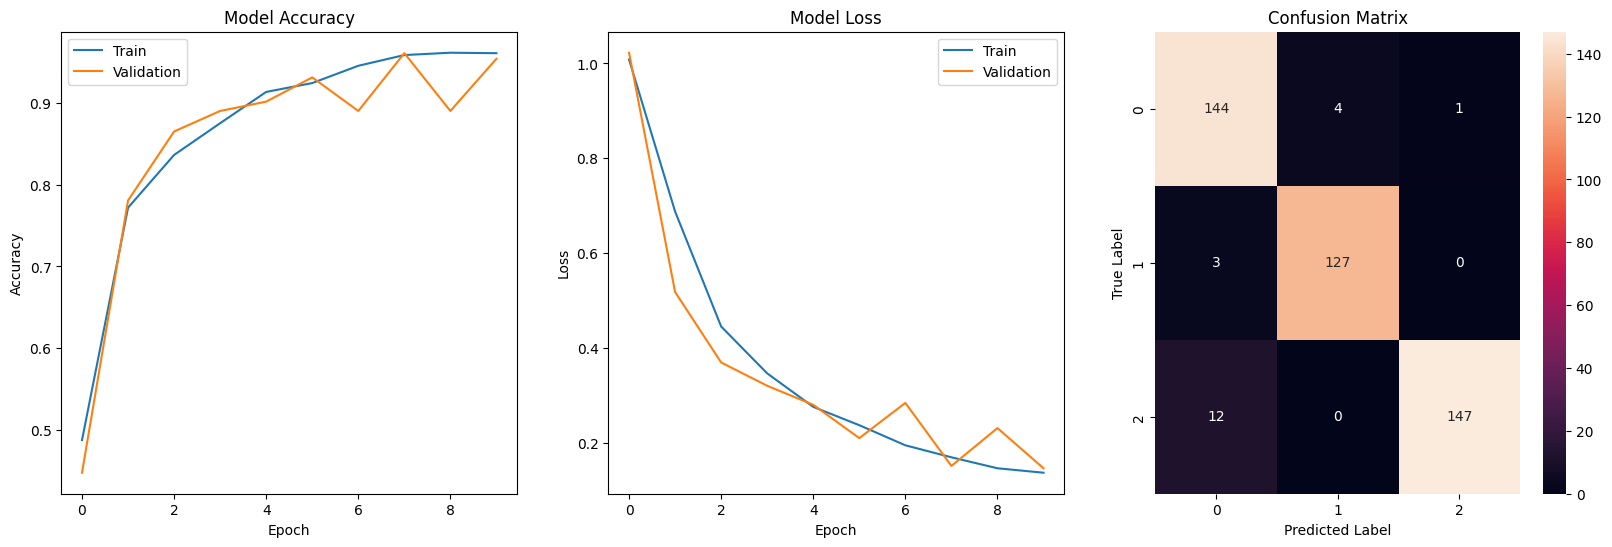


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       149
           1       0.97      0.98      0.97       130
           2       0.99      0.92      0.96       159

    accuracy                           0.95       438
   macro avg       0.96      0.96      0.96       438
weighted avg       0.96      0.95      0.95       438

Total Parameters: 93635
Training Time: 53.67 seconds
Evaluation Time: 0.45 seconds
Prediction Time: 0.62 seconds


In [81]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### We see that the results are promising.

## B. Use Key CNN Components and Explain Their effect.

### Kernel Size
#### Let's increase the size of kernel

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9703 - loss: 0.0775
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


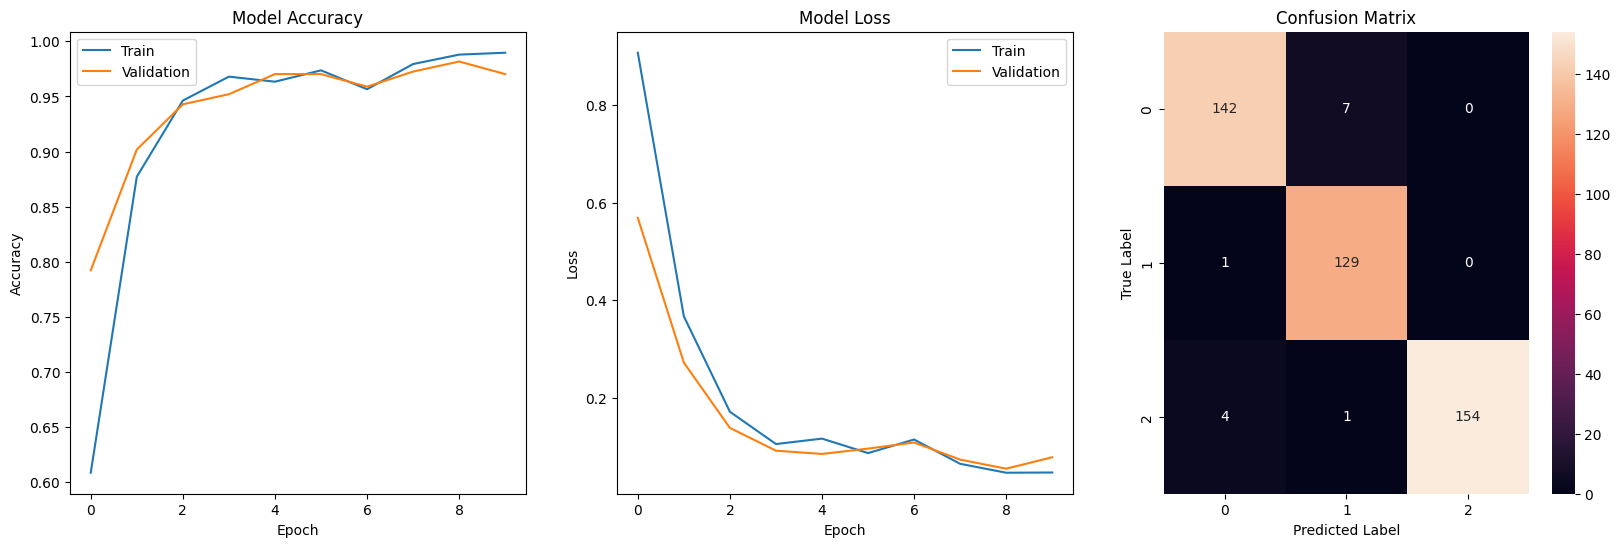


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       149
           1       0.94      0.99      0.97       130
           2       1.00      0.97      0.98       159

    accuracy                           0.97       438
   macro avg       0.97      0.97      0.97       438
weighted avg       0.97      0.97      0.97       438

Total Parameters: 662115
Training Time: 94.72 seconds
Evaluation Time: 0.90 seconds
Prediction Time: 0.80 seconds


In [82]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (8,8)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(32,kernel, activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,kernel, activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128,kernel, activation='relu'),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### The results improved. This means that the important features has larger size; The more general picture is containing info (shape of hand and the placement of fingers) rather than somethings like edges.
#### Both train and validation metrics are rather high, so no under or overfitting occured. The number of parameters and computation time increased, which makes sense.

### Strides
#### We set strides to 2 in both directions.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9749 - loss: 0.0676
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


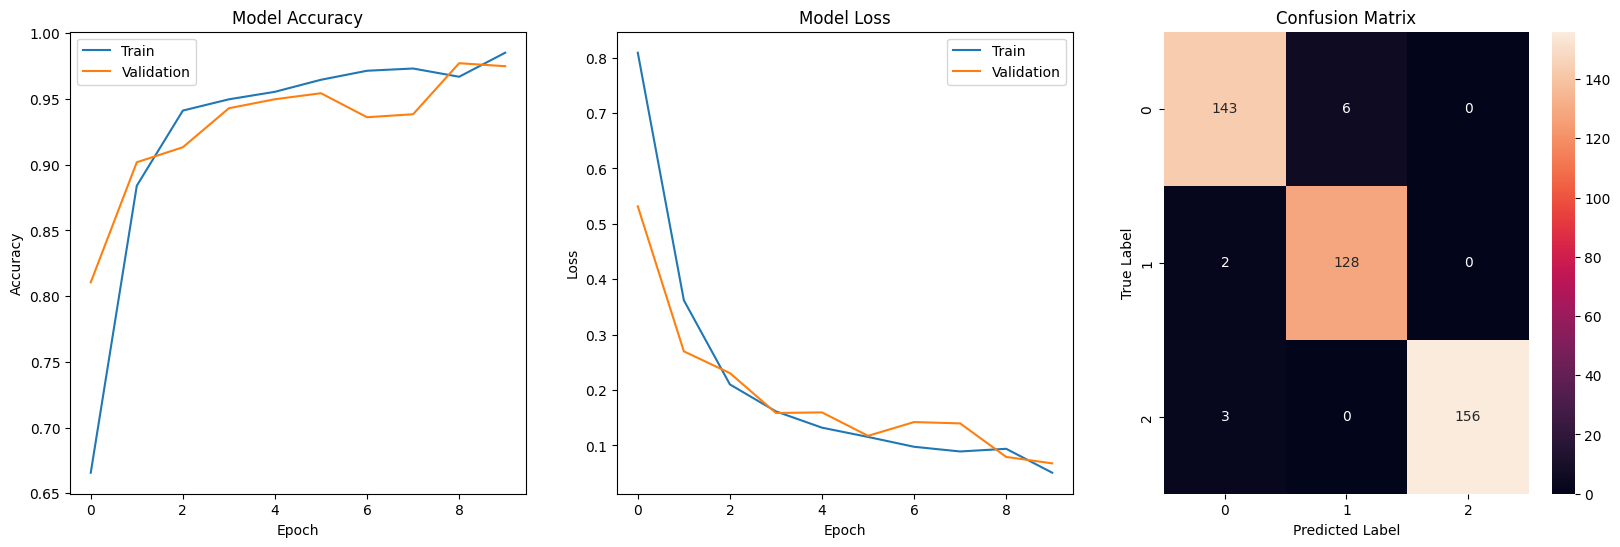


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       149
           1       0.96      0.98      0.97       130
           2       1.00      0.98      0.99       159

    accuracy                           0.97       438
   macro avg       0.97      0.98      0.97       438
weighted avg       0.98      0.97      0.97       438

Total Parameters: 93635
Training Time: 10.65 seconds
Evaluation Time: 0.16 seconds
Prediction Time: 0.26 seconds


In [83]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)
strides = (2,2)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(32,kernel, activation='relu', input_shape=(64, 64, 3), strides=strides),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,kernel, activation='relu', strides=strides),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128,kernel, activation='relu', strides=strides),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### The results are virtually the same as the original one. No overfitting or underfitting has happened.
#### Computation time and the number of parameters has been significantly reduced however, thanks to the strides, many calculation instances have been skipped.
#### Noitce that using strides we were able to get better results than large kernel, with less computation by a large margin; All while they are conceptually doing the same thing.

### Number Of Filters

### We increase the number of filters.

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9772 - loss: 0.0685
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step


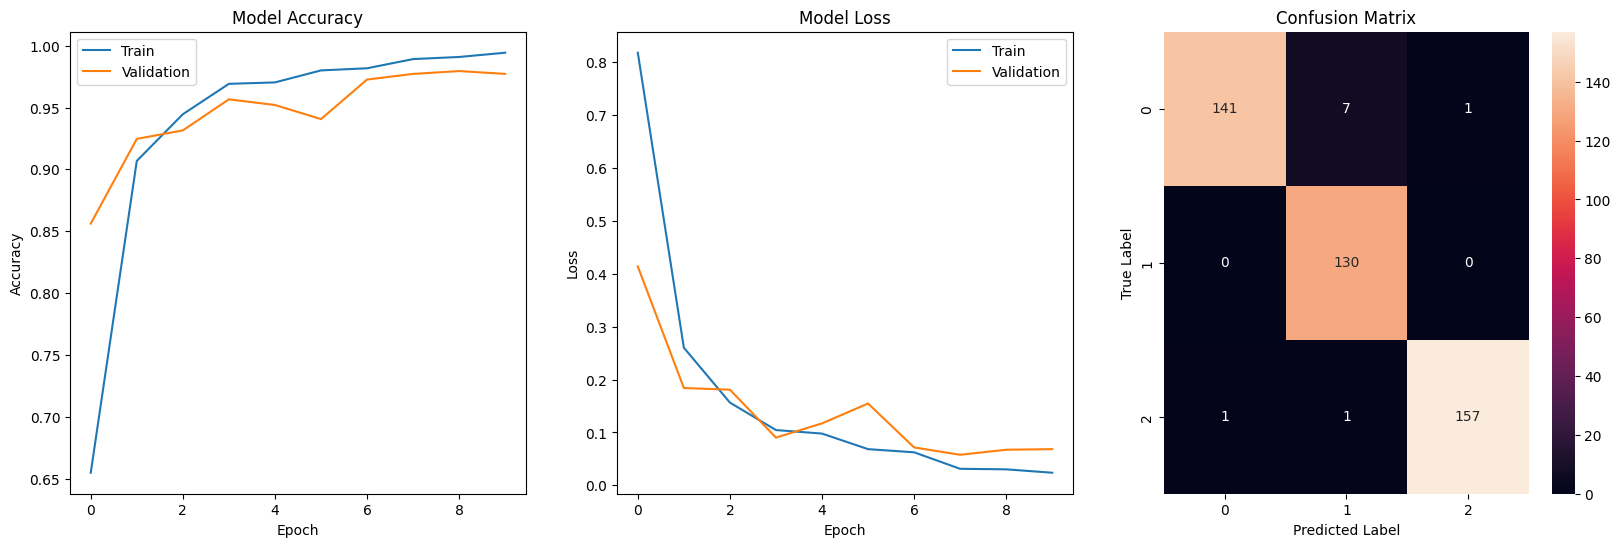


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       149
           1       0.94      1.00      0.97       130
           2       0.99      0.99      0.99       159

    accuracy                           0.98       438
   macro avg       0.98      0.98      0.98       438
weighted avg       0.98      0.98      0.98       438

Total Parameters: 18908163
Training Time: 818.89 seconds
Evaluation Time: 2.01 seconds
Prediction Time: 2.15 seconds


In [86]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)
strides = (2,2)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(1024,kernel, activation='relu', input_shape=(64, 64, 3), strides=strides),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(1024,kernel, activation='relu', strides=strides),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(1024,kernel, activation='relu', strides=strides),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### Decreasing the number of filters means a weaker network that might not be able to do the task with the required accuracy. The more interesting case is what happens when we increase the number of layers.
#### The results indicate that there is probably a point, beyond which the model is in a sort of saturation mode, and the metric no longer improve as the number of filters increaseing. So it is basically just a waste of resources and time.

### Polling Type & Polling Window Size
#### There are two types of polling startegies, max polling and average polling. for the last layer which is a global polling layer, meaning there is no window and all the features are filtered down to a single vector, a max polling layer could be overeacting to features (i.e. edges) which is not aligned with our task here as we saw previously that the larger and smoother features (i.e. fingers' positions) are the determinning factors. So we use a global average polling layer as the last polling layer
#### But for the other ones, let's try the other type.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9498 - loss: 0.1132
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


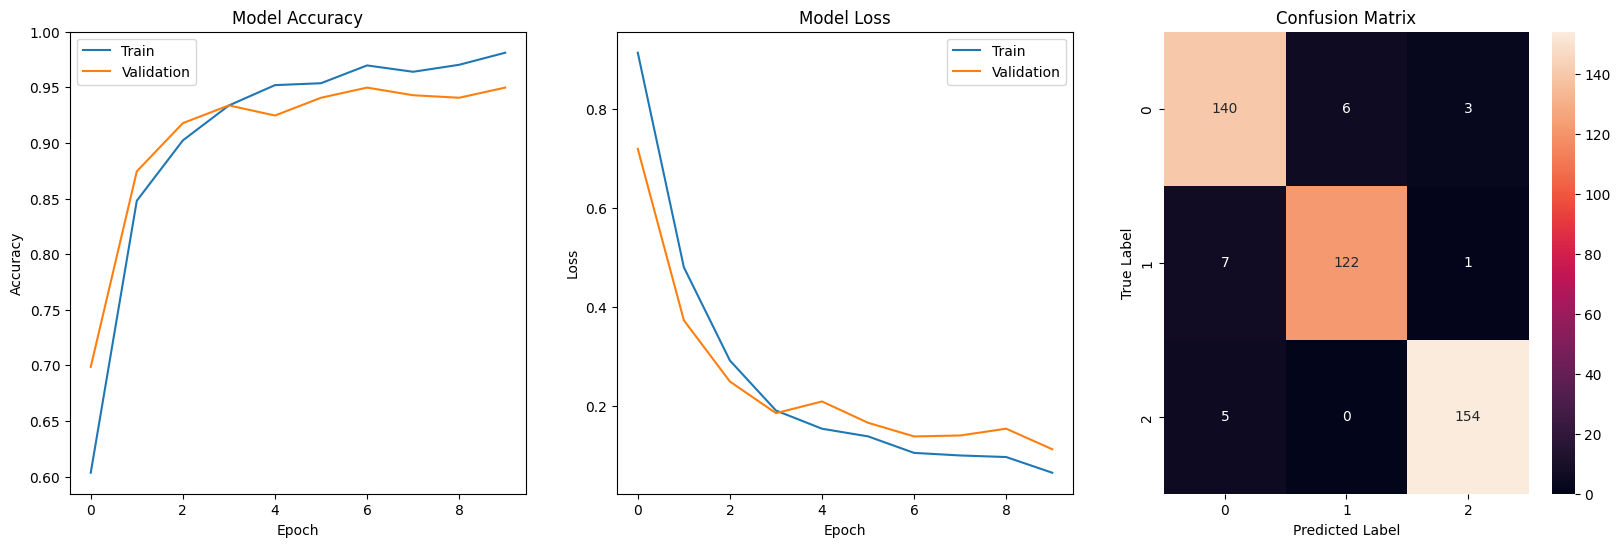


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       149
           1       0.95      0.94      0.95       130
           2       0.97      0.97      0.97       159

    accuracy                           0.95       438
   macro avg       0.95      0.95      0.95       438
weighted avg       0.95      0.95      0.95       438

Total Parameters: 93635
Training Time: 11.23 seconds
Evaluation Time: 0.16 seconds
Prediction Time: 0.26 seconds


In [88]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)
strides = (2,2)
polling_window = (2,2)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(32,kernel, activation='relu', input_shape=(64, 64, 3), strides=strides),
    layers.AveragePooling2D(polling_window),
    layers.Conv2D(64,kernel, activation='relu', strides=strides),
    layers.AveragePooling2D(polling_window),
    layers.Conv2D(128,kernel, activation='relu', strides=strides),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### As might have guessed, cherry picking strong features (max polling) does not help us in our task and the results have been slightly worsened. The computation time and the number of parameters does not change with the type of pooling layer.

#### Now let's see the effect of window size in pooling layers.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9909 - loss: 0.0484
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


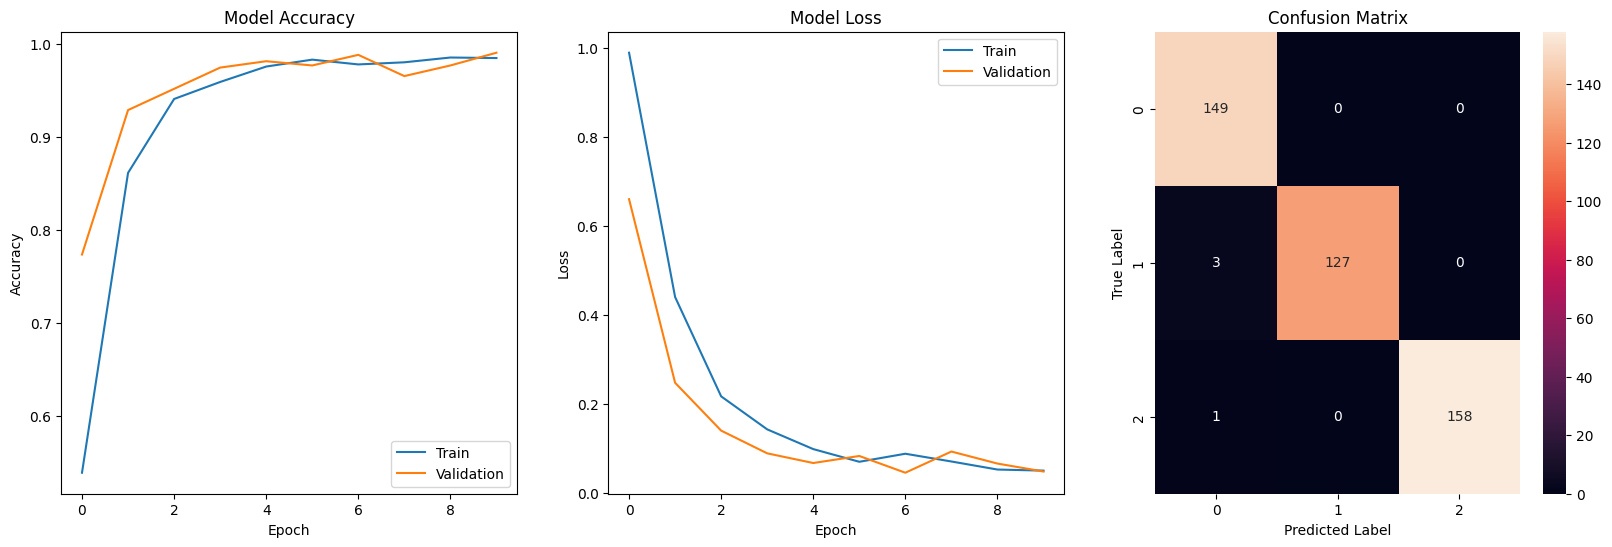


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       149
           1       1.00      0.98      0.99       130
           2       1.00      0.99      1.00       159

    accuracy                           0.99       438
   macro avg       0.99      0.99      0.99       438
weighted avg       0.99      0.99      0.99       438

Total Parameters: 93635
Training Time: 27.32 seconds
Evaluation Time: 0.31 seconds
Prediction Time: 0.38 seconds


In [93]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)
polling_window = (3,3)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(32,kernel, activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPool2D(polling_window),
    layers.Conv2D(64,kernel, activation='relu'),
    layers.MaxPool2D(polling_window),
    layers.Conv2D(128,kernel, activation='relu'),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### Note that in order to avoid shrinking the image into zero size, we had to remove the strides, so we should actually compare this model with the very first case.
#### Comparing the two, the one with the larger window is arguably slightly better, again because of imprtance of large scale features.

### Depth 
#### Obviously decreasing the number of layers can make the model weak enough so it can not predict with the reqiured accuracy anymore. So we examine the effect of increasing it.

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9817 - loss: 0.0451
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step


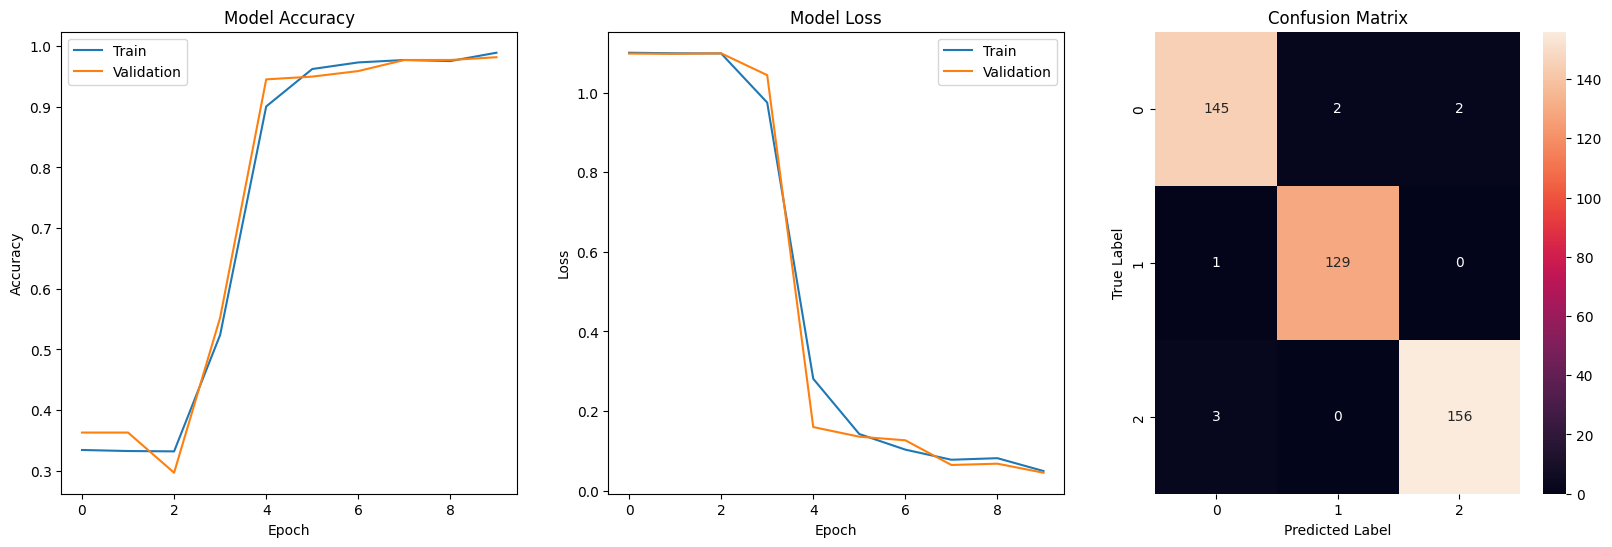


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       149
           1       0.98      0.99      0.99       130
           2       0.99      0.98      0.98       159

    accuracy                           0.98       438
   macro avg       0.98      0.98      0.98       438
weighted avg       0.98      0.98      0.98       438

Total Parameters: 688451
Training Time: 322.24 seconds
Evaluation Time: 2.17 seconds
Prediction Time: 2.42 seconds


In [110]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.Conv2D(64,kernel, activation='relu', padding="same", input_shape=(64, 64, 3)),
    layers.Conv2D(64,kernel, activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128,kernel, activation='relu', padding='same'),
    layers.Conv2D(128,kernel, activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256,kernel, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(512, activation='relu'),
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### We see that eventhough we increase both depth and width (capacity) of the model, the model still didn't overfitt. There could multiple reasons behind this, one them maybe that before the model is able to learn "too much" and "memorize noise" the data is shrunk down so much that it is no longer possible to overfitt.
#### Computation resources and time will increase by a large amount though.

## C. Data Augmentation
#### We apply random transforms on the images right at the beginning of the network.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9361 - loss: 0.2124
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


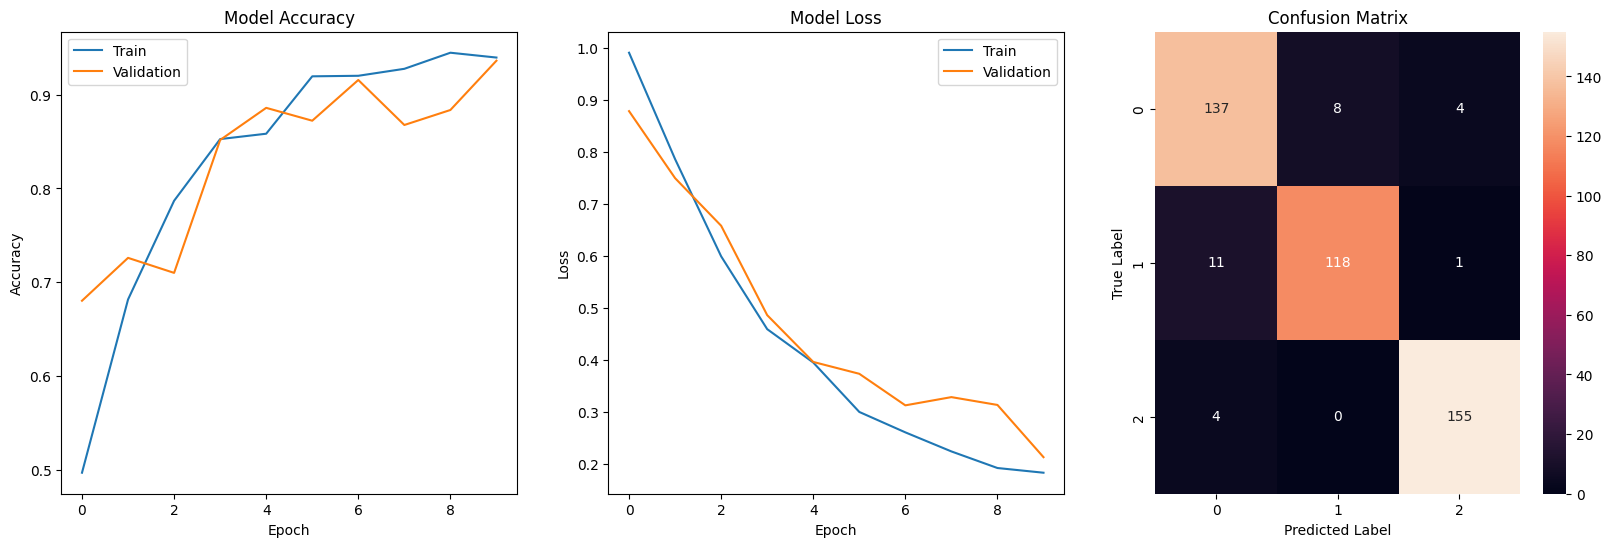


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       149
           1       0.94      0.91      0.92       130
           2       0.97      0.97      0.97       159

    accuracy                           0.94       438
   macro avg       0.94      0.93      0.93       438
weighted avg       0.94      0.94      0.94       438

Total Parameters: 93635
Training Time: 34.02 seconds
Evaluation Time: 0.27 seconds
Prediction Time: 0.37 seconds


In [112]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)
polling_window = (3,3)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.4),
    layers.RandomZoom(0.1),
    layers.Conv2D(32,kernel, activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPool2D(polling_window),
    layers.Conv2D(64,kernel, activation='relu'),
    layers.MaxPool2D(polling_window),
    layers.Conv2D(128,kernel, activation='relu'),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### We see that accuracy has decreased, which was expected. But the point is that if we can somehow increase the accuracy of this model, then the model will be more robust and resistant to transofrms like rotation in the input. 

#### Next we tamper with the color of the images.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4772 - loss: 1.0960
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


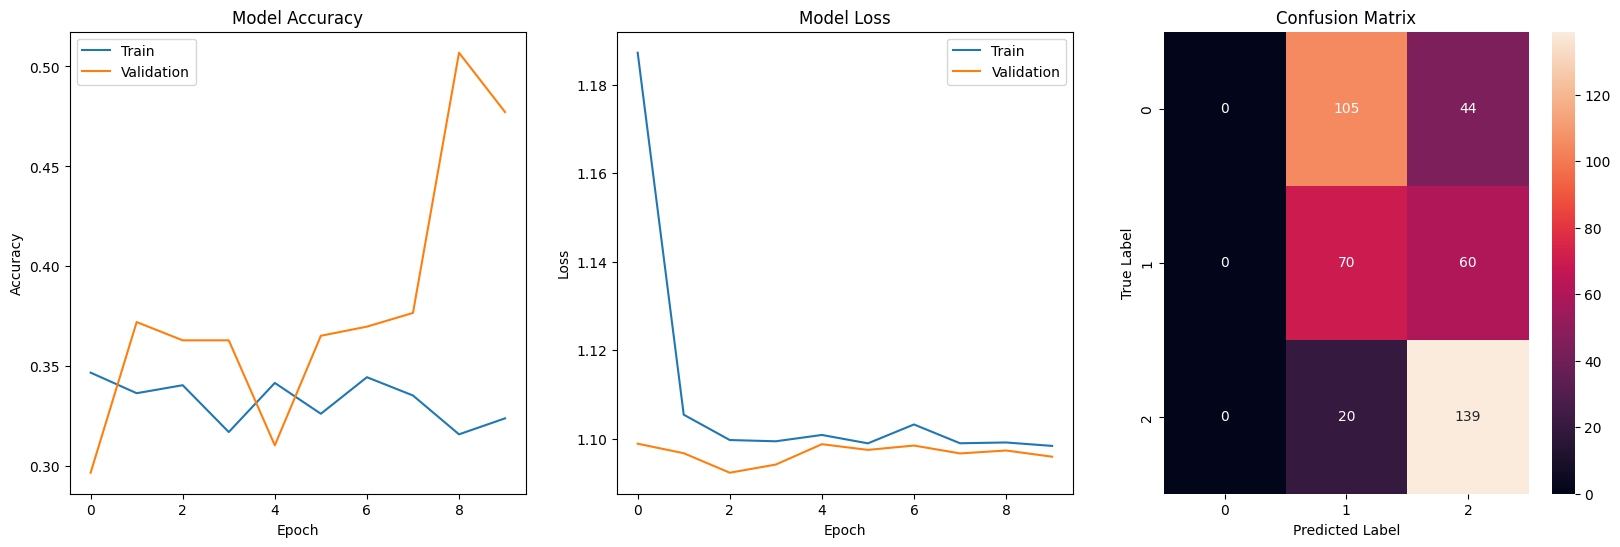


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       149
           1       0.36      0.54      0.43       130
           2       0.57      0.87      0.69       159

    accuracy                           0.48       438
   macro avg       0.31      0.47      0.37       438
weighted avg       0.31      0.48      0.38       438

Total Parameters: 93635
Training Time: 27.45 seconds
Evaluation Time: 0.25 seconds
Prediction Time: 0.40 seconds


In [114]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

kernel = (3,3)
polling_window = (3,3)

# Build CNN with GlobalAveragePooling2D
model = models.Sequential([
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.Conv2D(32,kernel, activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPool2D(polling_window),
    layers.Conv2D(64,kernel, activation='relu'),
    layers.MaxPool2D(polling_window),
    layers.Conv2D(128,kernel, activation='relu'),
    layers.GlobalAveragePooling2D(),  # Polling layer
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### The results indicate that color changes down right destroy our model, where as rotation, just decreased the accuracy ever so slightly. We may again use suitable measures to fortify our model against color changes.
#### Note that our model has leaned on the too weak side of the result meaning it failed to the tasks properoly. But there is a chance that, if our model has too much capacity, it would actually overfit instead of uunderfit.

### D. Transfer Learning
#### We use MobileNetV2 to extract features then use or own model.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9817 - loss: 0.0511
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step


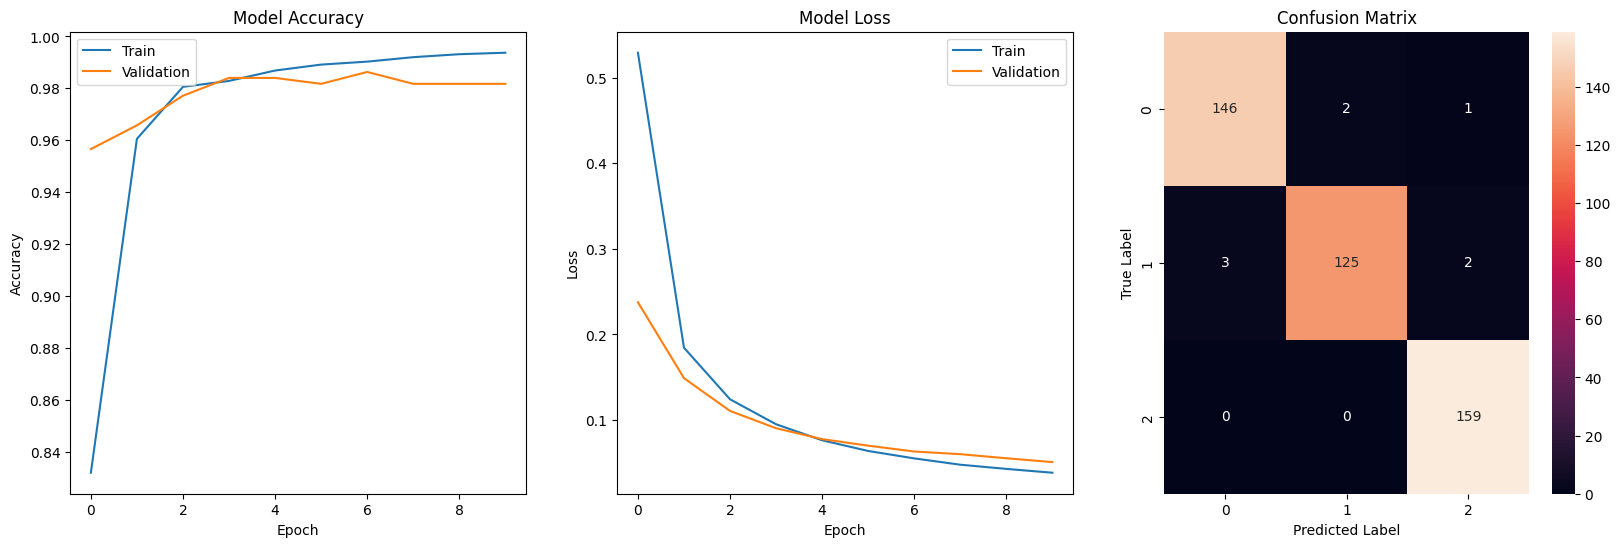


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       149
           1       0.98      0.96      0.97       130
           2       0.98      1.00      0.99       159

    accuracy                           0.98       438
   macro avg       0.98      0.98      0.98       438
weighted avg       0.98      0.98      0.98       438

Total Parameters: 2261827
Training Time: 53.94 seconds
Evaluation Time: 0.95 seconds
Prediction Time: 3.02 seconds


In [4]:
X = np.array(data, dtype=np.float32) / 255.0
y = np.array(pd.Categorical(labels).codes)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Clear session
K.clear_session()

base_model = MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze pretrained weights

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    # layers.Dense(128, activation='relu'),
    layers.Dense(len(np.unique(labels)), activation='softmax')
])

# Compile and train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# model.summary()

start_time = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=False)
train_time = time.time() - start_time

# Evaluate
start_time = time.time()
loss, acc = model.evaluate(X_val, y_val)
eval_time = time.time() - start_time

# Prediction
start_time = time.time()
y_pred_probs = model.predict(X_val)
pred_time = time.time() - start_time

plot_results(history, 
            y_val, 
            y_pred_probs, 
            train_time, 
            eval_time, 
            pred_time,
            model.count_params()
            )

#### The reason we chose MobileNetV2, is its efficieny and lightness. The data (images) is rather clean and does not contain noise, thus does not need a complex model. Another reason is that this project is being run on CPU, so we can not train large and heavy models. Furthermore the model has proper performance.
#### We froze all layers, because the model is already trained properly and does not need training. We could unfreeze some of last models (fine tunning) but it is a matter of tase.
#### Comparing this version with the best that we could achieve, we see that the results are everso slightly worse, but the computation time is consideerably longer.

### E. Discussion Question


### Why are CNNs more parameter-efficient than MLPs?

CNNs are more parameter-efficient because they exploit two key ideas:

- **Local connectivity**: Each neuron only processes a small local region of the image (e.g., 3×3 patch), instead of the entire input.
- **Weight sharing**: The same convolutional filter is applied across all spatial locations in the image.

This leads to:
- Far fewer parameters compared to fully connected layers
- Reuse of learned features (e.g., edges, textures) across the image
- Parameter count that does **not scale explosively** with image size

In contrast, an MLP:
- Connects every input pixel to every neuron in the next layer
- Has no notion of spatial structure
- Results in a very large number of parameters for image inputs

---

### When could an MLP theoretically match CNN performance?

In theory, an MLP could match a CNN if:

- It has **sufficient capacity (enough neurons and layers)** to represent spatial relationships
- It is trained on a **very large dataset**
- It is able to learn hierarchical features (edges → shapes → objects) from scratch

Mathematically, an MLP is a universal function approximator, so it *can* represent the same mapping as a CNN.

---

### Why is this unrealistic in practice?

In real-world applications, this is not practical because:

- **Parameter explosion**: Image inputs lead to extremely large fully connected layers (e.g., 64×64×3 = 12,288 inputs)
- **High computational cost**: Training and inference become very expensive
- **Poor sample efficiency**: Requires much more data to learn spatial structure from scratch
- **No inductive bias**: MLPs do not encode spatial locality or translation invariance, unlike CNNs

---

### Key takeaway

- CNNs are efficient because they incorporate **image-specific inductive biases (locality + weight sharing)**.
- MLPs can theoretically match CNNs, but only with **extreme computational and data requirements**, making them impractical for vision tasks.